Index type:  <class 'pandas.core.indexes.range.RangeIndex'>
Date range:  0  to  421569


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


,Store,Dept,Weekly_Sales,IsHoliday
Date,,,,
2010-02-05,1,1,24924.50,False
2010-02-12,1,1,46039.49,True
2010-02-19,1,1,41595.55,False
2010-02-26,1,1,19403.54,False
2010-03-05,1,1,21827.90,False


Example series -> Store=1, Dept=1, rows=143


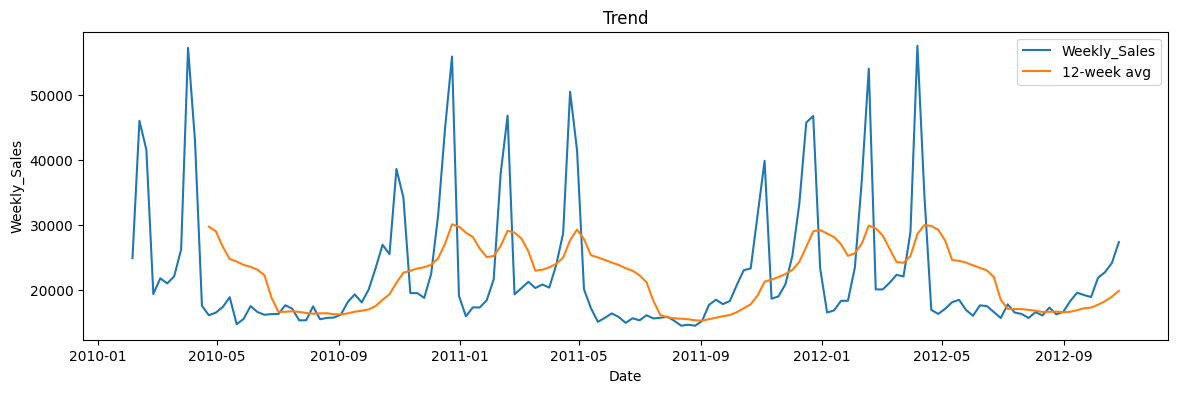

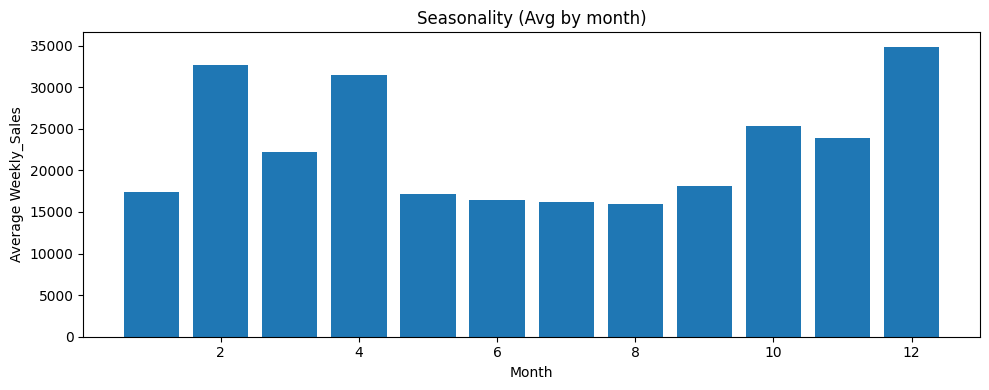

,Model,MAE,MSE,RMSE
0,Naive,4867.5675,3.230206e+07,5683.489715
1,Rolling Mean,4928.6900,3.290083e+07,5735.924258


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  

SARIMAX MAE:  3563.003209192112
SARIMAX MSE:  20541465.767335


,Model,MAE,MSE,RMSE
0,ARIMA,1782.931959,5600480.109108,2366.533353
1,SARIMAX,3563.003209,20541465.767335,4532.269384
2,XGBoost,1329.838965,3770969.358539,1941.89839


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return pd.Series({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

df=pd.read_csv("train.csv")
df['Date'] = pd.to_datetime(df['Date'])   #Data parsing

#Time indexing
df=df.sort_values(["Store","Dept","Date"]).reset_index(drop = True)
df=df.set_index(["Store","Dept","Date"]).reset_index()
print("Index type: ", type(df.index))
print("Date range: " , df.index.min() , " to " , df.index.max() )
display(df.head())

#Time series
store_id = 1
dept_id = 1
ts = df[(df["Store"] == store_id) & (df["Dept"] == dept_id)].copy()
ts = ts.set_index("Date")
ts = ts.sort_index()
display(ts.head())

print(f"Example series -> Store={store_id}, Dept={dept_id}, rows={len(ts)}")

#TREND (Rolling Average)
ts["roll_12"] = ts["Weekly_Sales"].rolling(12).mean()

#Plotting (Trend)
plt.figure(figsize=(14,4))
plt.plot(ts["Weekly_Sales"], label="Weekly_Sales")
plt.plot(ts["roll_12"], label="12-week avg")
plt.title("Trend")
plt.xlabel("Date")
plt.ylabel("Weekly_Sales")
plt.legend()
plt.show()

#Seasonality (Average by month)
seasonality_df = ts.reset_index()
seasonality_df["month"] = seasonality_df["Date"].dt.month
month_avg = seasonality_df.groupby("month")["Weekly_Sales"].mean()

#Plotting (Seasonality)
plt.figure(figsize=(10,4))
plt.bar(month_avg.index, month_avg.values)
plt.title("Seasonality (Avg by month)")
plt.xlabel("Month"); plt.ylabel("Average Weekly_Sales")
plt.tight_layout()
plt.show()

#Time-based train/test split
forecast_horizon = 8
train = ts.iloc[:-forecast_horizon]
test = ts.iloc[-forecast_horizon:]
y_train = train["Weekly_Sales"]
y_test = test["Weekly_Sales"]

#Baseline 1: Native forecast
last_value = y_train.iloc[-1]
naive_forecast = np.repeat(last_value, forecast_horizon)

#Baseline 2: Rolling mean forecast
rolling_window = 12
rolling_mean_value = y_train.iloc[-rolling_window:].mean()
rolling_forecast = np.repeat(rolling_mean_value, forecast_horizon)

#Evaluate baselines

baseline_results = pd.DataFrame([
    evaluate_forecast(y_test, naive_forecast, "Naive"),
    evaluate_forecast(y_test, rolling_forecast, "Rolling Mean")
])

display(baseline_results)

#Arima (1,1,1)
#d = 1 handles trend via differencing

arima_model = ARIMA(y_train, order=(1,1,1))
arima_model_fit = arima_model.fit()

# 2. Forecast future values
arima_forecast = arima_model_fit.forecast(steps=forecast_horizon)

#3. Evaluate ARIMA
arima_results = evaluate_forecast(y_test, arima_forecast, "ARIMA")

#4. Compare all models
all_results = pd.concat([baseline_results, arima_results.to_frame().T])
all_results



#Time based split
train = ts.iloc[:-forecast_horizon]
test = ts.iloc[-forecast_horizon:]

y_train = train["Weekly_Sales"]
y_test = test["Weekly_Sales"]

#Fit SARIMAX

sarimax_model = SARIMAX(
    endog=y_train,
    order=(1,1,1),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fitted = sarimax_model.fit(disp=False)

#Forecast
sarimax_forecast = sarimax_fitted.forecast(steps=forecast_horizon)


#Evaluate
mae = mean_absolute_error(y_test, sarimax_forecast)
mse = mean_squared_error(y_test, sarimax_forecast)
print("SARIMAX MAE: ", mae)
print("SARIMAX MSE: ", mse)

# XGBOOST

xgb_ts = ts[["Weekly_Sales", "IsHoliday"]].copy()
xgb_ts["IsHoliday"] = xgb_ts["IsHoliday"].astype(int)

def make_features(data):
    data = data.copy()

    for lag in [1, 2, 4, 8, 52]:
        data[f"lag_{lag}"] = data["Weekly_Sales"].shift(lag)

    data["rolling_mean_4"] = data["Weekly_Sales"].shift(1).rolling(4).mean()
    data["rolling_mean_8"] = data["Weekly_Sales"].shift(1).rolling(8).mean()
    data["rolling_std_4"] = data["Weekly_Sales"].shift(1).rolling(4).std()

    data["month"] = data.index.month
    data["week_of_year"] = data.index.isocalendar().week.astype(int)

    return data

xgb_feat = make_features(xgb_ts).dropna()

xgb_train = xgb_feat.iloc[:-forecast_horizon]
xgb_test = xgb_feat.iloc[-forecast_horizon:]

y_train_xgb = xgb_train["Weekly_Sales"]
y_test_xgb = xgb_test["Weekly_Sales"]

feature_cols = [
    "lag_1", "lag_2", "lag_4", "lag_8", "lag_52",
    "rolling_mean_4", "rolling_mean_8", "rolling_std_4",
    "month", "week_of_year", "IsHoliday"
]

X_train = xgb_train[feature_cols]
X_test = xgb_test[feature_cols]

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train_xgb)

xgb_forecast = xgb_model.predict(X_test)

xgb_results = evaluate_forecast(y_test_xgb, xgb_forecast, "XGBoost")

sarimax_results = evaluate_forecast(y_test, sarimax_forecast, "SARIMAX")

model_results = pd.concat([
    arima_results.to_frame().T,
    sarimax_results.to_frame().T,
    xgb_results.to_frame().T
], ignore_index=True)

display(model_results)

